# GraphMind: Offline Workflow Extraction

This notebook runs the GraphMind §3.2 extraction pipeline on one of two tracks, selected via the `TRACK` toggle below:

- `"incidents"` (default) — anonymized ICM traces in `data/incident_rca/test_input_*.json`.
- `"spreadsheet"` — SpreadsheetBench records in `data/spreadsheet/*.jsonl` (generalizability experiment).

All cells below the toggle are track-agnostic: they call `extract_one()` and `summarize_workflow_graph()` on whatever the loader produced. Section 8 (per-track plots) is guarded and only runs when its track is selected.

## 1. Choose dataset track

Flip `TRACK` to switch between the two datasets. All other cells depend only on this one variable.

In [1]:
from pathlib import Path

TRACK = "incidents"       # "incidents" | "spreadsheet"
SPREADSHEET_FILE = "train_sample.jsonl"   # or "train_124.jsonl" for the full set

OUTPUT_DIR = Path("outputs/incident_rca") if TRACK == "incidents" else Path("outputs/spreadsheet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"TRACK={TRACK}  OUTPUT_DIR={OUTPUT_DIR}")


TRACK=incidents  OUTPUT_DIR=outputs/incident_rca


## 2. Install dependencies

In [2]:
%pip install pocketflow openai tiktoken dirtyjson beautifulsoup4 --quiet

Note: you may need to restart the kernel to use updated packages.


## 3. Configure LLM credentials

Set Azure OpenAI environment variables (default), or set `GRAPHMIND_USE_AZURE=0` plus `OPENAI_API_KEY` for standard OpenAI.

In [ ]:
import os

# Fill these in (or set them in your shell before launching Jupyter).
os.environ["AZURE_OPENAI_API_KEY"] = os.environ.get("AZURE_OPENAI_API_KEY", "")
os.environ["AZURE_OPENAI_ENDPOINT"] = os.environ.get("AZURE_OPENAI_ENDPOINT", "")
os.environ["AZURE_OPENAI_DEPLOYMENT"] = os.environ.get("AZURE_OPENAI_DEPLOYMENT", "gpt-5.2")
os.environ["AZURE_OPENAI_EMBED_DEPLOYMENT"] = os.environ.get("AZURE_OPENAI_EMBED_DEPLOYMENT", "text-embedding-3-large")
os.environ["AZURE_OPENAI_API_VERSION"] = os.environ.get("AZURE_OPENAI_API_VERSION", "2025-04-01-preview")
os.environ["GRAPHMIND_USE_AZURE"] = "1"

## 4. Imports

In [4]:
import json
from pathlib import Path

import dirtyjson

from graphmind import (
    extract_workflow_graph_from_dict,
    extract_workflow_graph_from_sample,
    summarize_workflow_graph,
    load_jsonl,
)

## 5. Load records

Returns a list of `(name, record)` pairs. The shape of `record` differs by track but the downstream cells don't care.

In [5]:
def load_records(track):
    if track == "incidents":
        files = sorted(Path("data/incident_rca").glob("test_input_*.json"))
        return [(f.stem, json.loads(f.read_text())) for f in files]
    if track == "spreadsheet":
        samples = load_jsonl(Path("data/spreadsheet") / SPREADSHEET_FILE)
        return [(str(s["id"]), s) for s in samples]
    raise ValueError(f"unknown track: {track}")

records = load_records(TRACK)
print(f"Loaded {len(records)} records from {TRACK} track")
for name, rec in records[:3]:
    if TRACK == "incidents":
        title = rec.get("metadata", {}).get("title", "N/A")
        n_comms = len(dirtyjson.loads(rec["raw"]).get("communications", []))
        print(f"  [{name}] {title[:80]}  (communications={n_comms})")
    else:
        print(f"  [{name}] {rec.get('instruction', '')[:80]}")

Loaded 2 records from incidents track
  [test_input_A] (zombie SQL error 19732)[CSS Sev B] [Lattice] [Ingestion] -  A connection was su  (communications=123)
  [test_input_B] [err 17830 state 105 timeout errors in Gateway and Xdbhost][CSS Sev C] [Lattice]  (communications=93)


## 6. Extract workflow graphs

Dispatches to the right extractor based on `TRACK`. Both produce the same `{domain, workflow_graph, id}` schema.

In [6]:
def extract_one(track, name, rec):
    if track == "incidents":
        domain = rec.get("metadata", {}).get("owning_team", "Unknown")
        return extract_workflow_graph_from_dict(rec, domain=domain, chunk_size=2000)
    return extract_workflow_graph_from_sample(rec)

# Skip LLM extraction if cached workflow_graph JSONs are already on disk
# (re-running clustering iterations is much faster this way). Delete
# files in OUTPUT_DIR to force re-extraction.
workflow_graphs = []
if TRACK == "incidents":
    cached = sorted(OUTPUT_DIR.glob("taxonomy_*.json"))
    name_for = lambda fp: f"test_input_{fp.stem.replace('workflow_graph_', '')}"
else:
    cached = sorted(OUTPUT_DIR.glob("*.json"))
    cached = [fp for fp in cached if not fp.stem.startswith("_")]
    name_for = lambda fp: fp.stem

if cached:
    for fp in cached:
        try:
            obj = json.loads(fp.read_text())
        except Exception:
            continue
        if isinstance(obj, dict) and "domain" in obj:
            workflow_graphs.append((name_for(fp), obj))
    print(f"loaded {len(workflow_graphs)} cached workflow graphs from {OUTPUT_DIR}")
else:
    for name, rec in records:
        print(f"\nExtracting [{name}]...")
        wf = extract_one(TRACK, name, rec)
        if wf is None:
            print(f"  [{name}] FAILED")
            continue
        short = name.replace("test_input_", "")
        out_path = OUTPUT_DIR / (f"taxonomy_{short}.json" if TRACK == "incidents" else f"{name}.json")
        out_path.write_text(json.dumps(wf, indent=2, ensure_ascii=False))
        workflow_graphs.append((name, wf))
        print(f"  saved {out_path}  domain={wf.get('domain')}  paths={len(wf.get('taxonomy', []))}")


loaded 2 cached workflow graphs from outputs/incident_rca


## 7. Summaries

In [7]:
for name, wf in workflow_graphs[:5]:
    summarize_workflow_graph(wf, name)


Workflow graph: test_input_taxonomy_A
Domain: CLOUDANALYTICS\ClientExperiences
Paths: 1

  Path 1 (11 nodes):
    [INCIDENT]   single_incident
    [PROBLEM]    SQL pool connections fail due to token errors
    [INCIDENT_TRANSFER] Transfer incident to client experiences team
    [PROBLEM]    Investigate moniker token failures causing login resets
    [KQL_QUERY   ] Query AppTrace for TdsSession RootActivityId
    [KQL_QUERY   ] Drill into AppTrace using RootActivityId
    [KQL_QUERY   ] Query AuthLogin by activity ID for rejection
    [INCIDENT_TRANSFER] Transfer incident to connectivity security team
    [SQL_QUERY   ] Run select @@version to validate connectivity
    [KQL_QUERY   ] Query AuthLogin by ClientConnectionId for reason
    [MITIGATION  ] Re-enable frontend auto-deactivation to prevent moniker eviction

Workflow graph: test_input_taxonomy_B
Domain: CLOUDANALYTICS\Connectivity-Security
Paths: 1

  Path 1 (13 nodes):
    [INCIDENT]   single_incident
    [PROBLEM]    Automated

## 8. Visualize results

Per-track plots over the extracted workflow_graphs. Each subsection runs only on its track and prints a skip message on the other:

- **8.1 / 8.2** — spreadsheet track: domain distribution, paths-per-workflow_graph histogram (only meaningful with many records).
- **8.3 / 8.4** — incidents track: steps per incident chain, step-type breakdown per incident.

In [8]:
from graphmind import viz
viz.set_save_dir(OUTPUT_DIR)

if TRACK == "spreadsheet":
    OURS_DIR = Path("outputs/spreadsheet")
    def _load(d):
        out = {}
        for fp in d.glob("*.json"):
            if fp.stem.startswith("_"):
                continue
            try:
                obj = json.loads(fp.read_text())
            except Exception:
                continue
            if isinstance(obj, dict) and "domain" in obj:
                out[fp.stem] = obj
        return out
    ours = _load(OURS_DIR)
    print(f"loaded {len(ours)} workflow_graphs from {OURS_DIR}")
else:
    print("skipping: section 8.1/8.2 are for the spreadsheet track")

skipping: section 8.1/8.2 are for the spreadsheet track


### 8.1 Domain distribution (spreadsheet track)

In [9]:
if TRACK == "spreadsheet":
    viz.plot_domain_distribution(ours)

### 8.2 Path count distribution (spreadsheet track)

In [10]:
if TRACK == "spreadsheet":
    viz.plot_paths_per_workflow_graph(ours)

### 8.3 Steps per incident (incidents track)

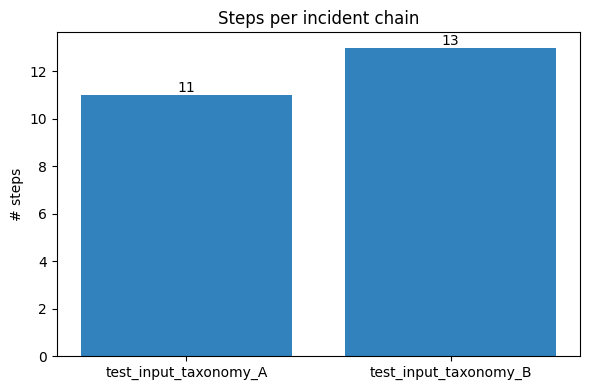

In [11]:
if TRACK == "incidents":
    viz.plot_steps_per_incident(workflow_graphs)
else:
    print("skipping: section 8.3 is for the incidents track")

### 8.4 Step-type breakdown per incident (incidents track)

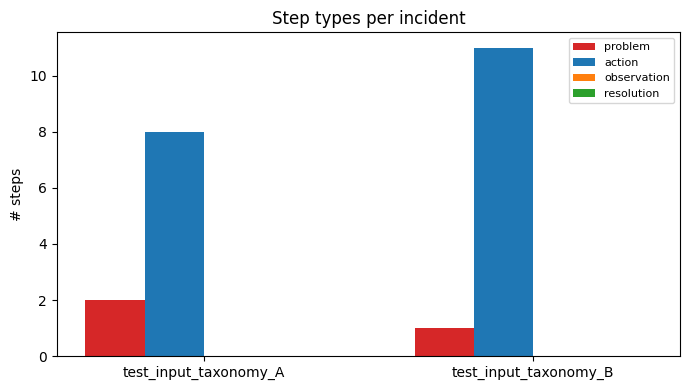

In [12]:
if TRACK == "incidents":
    viz.plot_step_types_per_incident(workflow_graphs)
else:
    print("skipping: section 8.4 is for the incidents track")

## 9. Build & cluster the workflow_graph graph

Merge all extracted workflow_graphs into one `networkx.DiGraph`, then collapse semantically-duplicate nodes via cosine + average-linkage agglomerative clustering. Uses Azure OpenAI `text-embedding-3-large` (set `AZURE_OPENAI_EMBED_DEPLOYMENT` in cell 6 to override).

### 9.1 Build graph

In [13]:
from copy import deepcopy

from graphmind import viz
from graphmind.graph import build_workflow_graph
from graphmind.clustering import cluster_graph
from graphmind.llm_client import AzureEmbedder

wf_docs = [wf for _, wf in workflow_graphs]
g_pre = build_workflow_graph(wf_docs)
print(f"pre-cluster : {g_pre.number_of_nodes():4d} nodes  {g_pre.number_of_edges():4d} edges")

pre-cluster :   22 nodes    20 edges


### 9.2 Run clustering

In [14]:
# Threshold tuned per corpus size and label density. Spreadsheet labels are
# formula-shaped but synonyms exist (e.g. "filter empty rows" / "drop blank
# rows") so a moderate threshold collapses them. Incident labels are short
# imperative phrases; with only 2 incidents in this public demo, a similar
# threshold yields the strongest organic AppTrace / AuthLogin merges between
# A and B. Production runs at 0.15 on ~12k nodes where co-occurrence density
# carries more of the signal.
threshold = 0.30 if TRACK == "incidents" else 0.45
g_post = deepcopy(g_pre)
cluster_graph(g_post, AzureEmbedder(), distance_threshold=threshold)
print(f"post-cluster: {g_post.number_of_nodes():4d} nodes  {g_post.number_of_edges():4d} edges  (threshold={threshold})")

INFO | HTTP Request: POST https://<AZURE_OPENAI_ENDPOINT>/openai/deployments/text-embedding-3-large/embeddings?api-version=2025-04-01-preview "HTTP/1.1 200 OK"


INFO | HTTP Request: POST https://<AZURE_OPENAI_ENDPOINT>/openai/deployments/text-embedding-3-large/embeddings?api-version=2025-04-01-preview "HTTP/1.1 200 OK"


post-cluster:   19 nodes    18 edges  (threshold=0.3)


### 9.3 Graph size before vs after

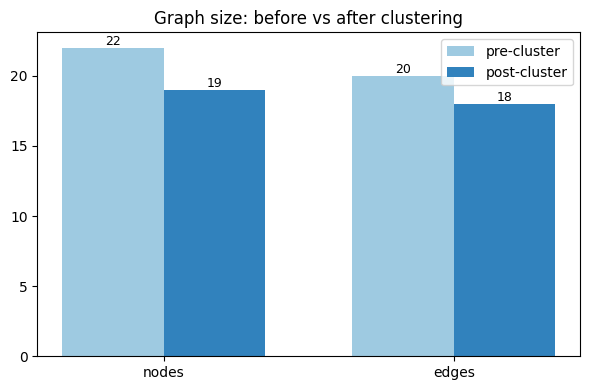

In [15]:
viz.plot_size_before_after(g_pre, g_post)

### 9.4 Node-type distribution

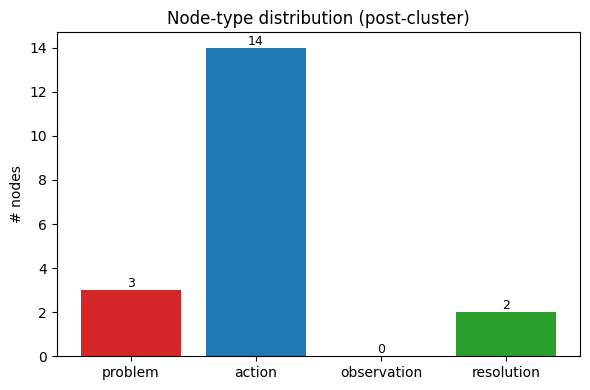

In [16]:
viz.plot_ntype_distribution(g_post)

### 9.5 Cluster size distribution

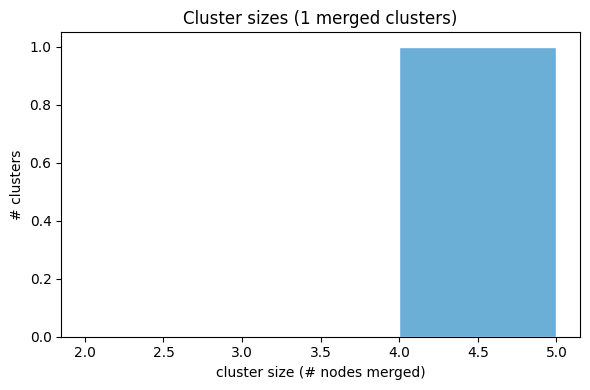

In [17]:
viz.plot_cluster_sizes(g_post)

### 9.6 Top-15 most frequent nodes

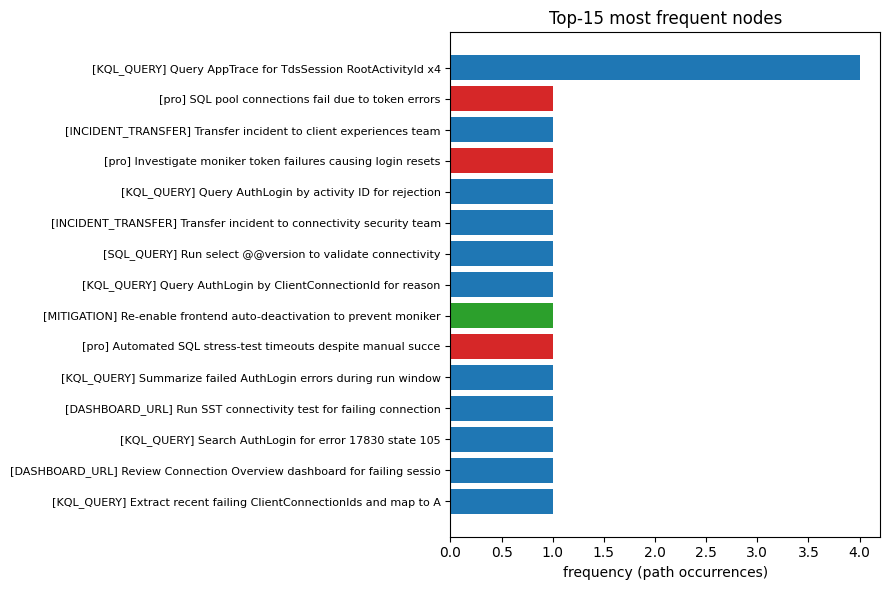

In [18]:
viz.plot_top_frequent(g_post, top_n=15)

### 9.7 Graph layout: before vs after clustering

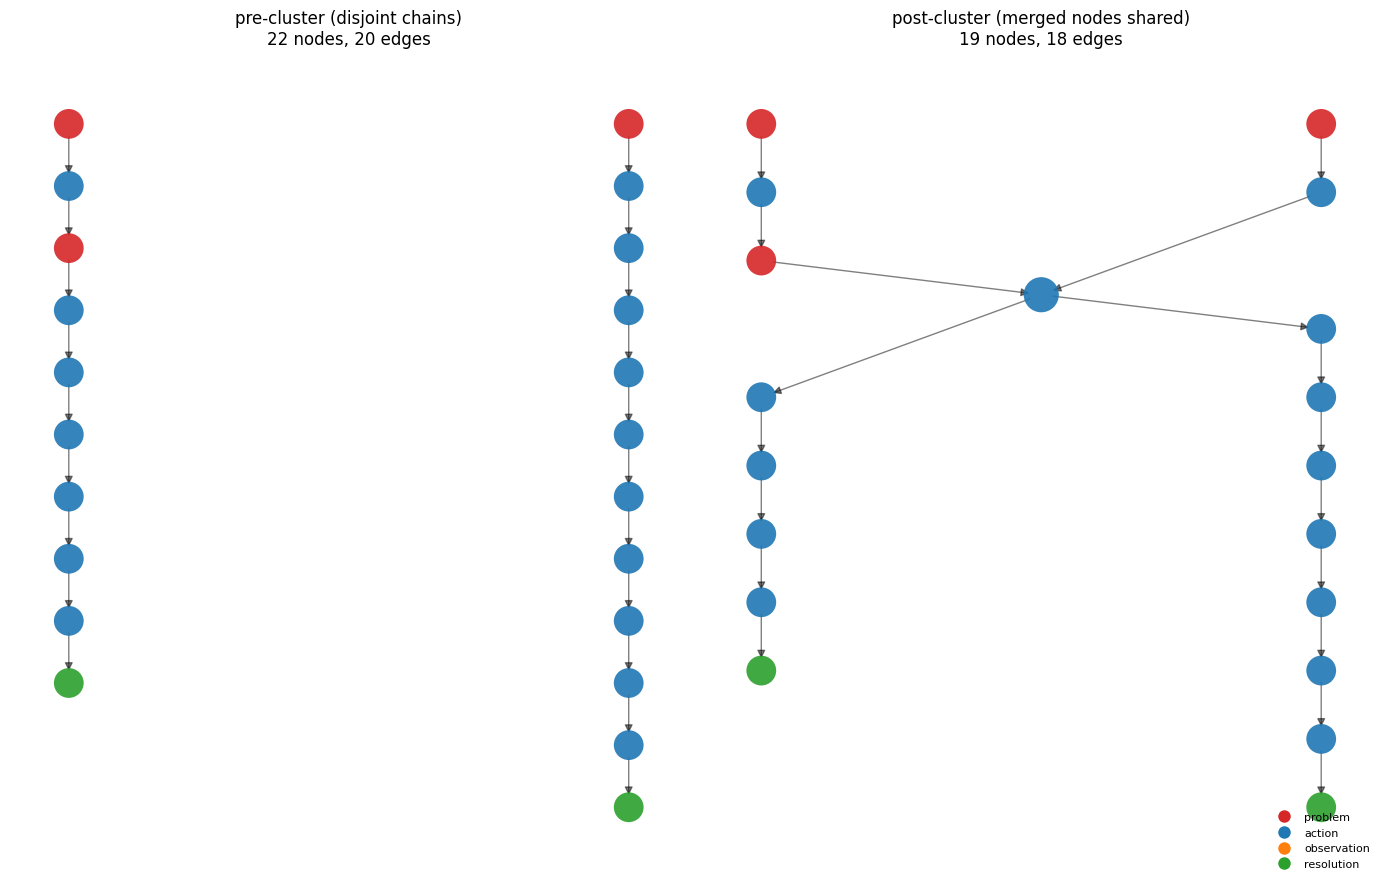

In [19]:
viz.plot_layout_before_after(g_pre, g_post, workflow_graphs, track=TRACK)

## 10. Schema mapping: paper → artifact

The production graph (paper §3.1) and the artifact graph are not identical — the artifact collapses some structure for portability. Here's exactly what's faithful and what's simplified:

| Paper construct (§3.1)             | Artifact representation (`graphmind/graph.py`)          | Notes |
|------------------------------------|----------------------------------------------------------|-------|
| **Node types**: Domain / Problem / Action | `ntype` ∈ {`problem`, `action`, `observation`, `resolution`} | Domain is stored as a per-node attr, not a separate node. Observation/Resolution are made explicit (paper folds them into Action context). |
| **Edge types**: CAUSES / RESOLVES / LEADS_TO / BELONGS_TO | single typed edge with `weight` (co-occurrence count) | Edge *direction* preserves the paper's causal/sequential semantics, but the explicit type label is dropped. |
| **Reinforcement weight φ(e)** (paper §5) | `weight` (co-occurrence; no online updates) | Artifact is offline only — no ATR loop. |
| **Clustering** (§3.3): canonicalize → embed → cosine + average-linkage agglomerative | `graphmind/clustering.py::cluster_graph` — same sklearn call as prod (`AgglomerativeClustering(metric="cosine", linkage="average")`) with the same Phase 1 regex canonicalizer (`graphmind/canonicalize.py`). | Matches the *"Ours"* variant in Fig 3. |
| **Representative selection** (§3.3): generated from longest/shortest/median of cluster members | Highest-frequency member of the cluster | Documented divergence. The paper variant requires an LLM call per cluster; the frequency heuristic is what production uses today. |
| **De-clustering** (§3.4): undo for incremental updates | Not implemented | Out of scope for a single-shot artifact run. |